# Student Performance Analysis

Clusters students by academic performance using K-Means, then generates career recommendations.

In [14]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [15]:
# ── Configuration ─────────────────────────────────────────────────────────────
DATA_PATH      = Path("students_dataset.csv")
MODEL_PATH     = Path("student_model.pkl")
OUTPUT_PATH    = Path("students_clustered.csv")
N_CLUSTERS     = 3
RANDOM_STATE   = 42

FEATURE_COLUMNS = [
    "attendance",
    "math_marks",
    "programming_marks",
    "communication_marks",
    "assignment_score",
]

ORDERED_LABELS  = ["At Risk", "Average", "Top Performer"]
CATEGORY_COLORS = {"At Risk": "#D53826", "Average": "#F58518", "Top Performer": "#4C78A8"}

In [16]:
# ── 1. Load & Validate Data ────────────────────────────────────────────────────
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

missing_columns = sorted(set(FEATURE_COLUMNS + ["name"]) - set(df.columns))
if missing_columns:
    raise ValueError(f"Dataset missing required columns: {missing_columns}")

# Drop rows with missing model features to avoid downstream training issues.
df = df.dropna(subset=FEATURE_COLUMNS).copy()

print("Dataset loaded successfully")
print(f"Rows: {len(df)} | Columns: {len(df.columns)}")
df.head()

Dataset loaded successfully
Rows: 300 | Columns: 8


,student_id,name,attendance,math_marks,programming_marks,communication_marks,assignment_score,career_interest
0,1,Kabir_0,79,66,71,62,60,Business
1,2,Aman_1,76,64,65,79,69,Data Science
2,3,Aditya_2,75,68,80,80,62,Design
3,4,Riya_3,88,84,89,97,85,Data Science
4,5,Vikram_4,89,100,86,83,81,Cybersecurity


In [17]:
# ── 2. Feature Scaling ─────────────────────────────────────────────────────────
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[FEATURE_COLUMNS])

# ── 3. Train K-Means ───────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init="auto")
df["cluster"] = kmeans.fit_predict(scaled_features)

print(f"K-Means trained  |  inertia: {kmeans.inertia_:.2f}")

K-Means trained  |  inertia: 206.48


In [18]:
# ── 4. Map Clusters → Performance Labels ──────────────────────────────────────
# Rank clusters by mean score across all features (low → high = At Risk → Top Performer).
cluster_means  = df.groupby("cluster")[FEATURE_COLUMNS].mean()
cluster_scores = cluster_means.mean(axis=1).sort_values()

if len(cluster_scores) != len(ORDERED_LABELS):
    raise ValueError(
        f"Expected {len(ORDERED_LABELS)} clusters, got {len(cluster_scores)}"
    )

cluster_label_map = dict(zip(cluster_scores.index, ORDERED_LABELS))
df["performance_category"] = df["cluster"].map(cluster_label_map)

# Summary per cluster
print("Cluster → Label mapping:")
for cid, label in cluster_label_map.items():
    n = (df["cluster"] == cid).sum()
    print(f"  cluster {cid} → {label:15s}  ({n} students)")

Cluster → Label mapping:
  cluster 1 → At Risk          (98 students)
  cluster 0 → Average          (106 students)
  cluster 2 → Top Performer    (96 students)


In [19]:
# ── 5. Career Recommendations ─────────────────────────────────────────────────
# Priority order: a student CAN match multiple conditions; we capture ALL matches
# and join them.  Falls back to "General Skill Development" if none apply.

CAREER_RULES = [
    (df["programming_marks"]   > 80, "Software Engineer / AI Engineer"),
    (df["math_marks"]           > 80, "Data Scientist / Finance Analyst"),
    (df["communication_marks"]  > 80, "Marketing / Business"),
]

def build_recommendations(row_index: pd.Index) -> pd.Series:
    """Return a Series of comma-joined career strings for each student."""
    matched = pd.DataFrame(
        {label: mask for mask, label in CAREER_RULES},
        index=row_index,
    )
    # Join all matched labels per row; default when nothing matches.
    recommendations = matched.apply(
        lambda row: ", ".join(row.index[row]) or "General Skill Development",
        axis=1,
    )
    return recommendations

df["career_recommendation"] = build_recommendations(df.index)

print(df[["name", "performance_category", "career_recommendation"]].head(10).to_string(index=False))

    name performance_category                                                                   career_recommendation
 Kabir_0              Average                                                               General Skill Development
  Aman_1              Average                                                               General Skill Development
Aditya_2              Average                                                               General Skill Development
  Riya_3        Top Performer Software Engineer / AI Engineer, Data Scientist / Finance Analyst, Marketing / Business
Vikram_4        Top Performer Software Engineer / AI Engineer, Data Scientist / Finance Analyst, Marketing / Business
 Pooja_5              Average                                                               General Skill Development
 Pooja_6              At Risk                                                               General Skill Development
 Karan_7              At Risk                           

In [20]:
# ── 6. Save Model & Results ────────────────────────────────────────────────────
# Persist scaler + kmeans together so predictions stay consistent.
with open(MODEL_PATH, "wb") as f:
    pickle.dump({"scaler": scaler, "kmeans": kmeans, "cluster_label_map": cluster_label_map}, f)

df.to_csv(OUTPUT_PATH, index=False)

print(f"Model saved  →  {MODEL_PATH}")
print(f"Results saved → {OUTPUT_PATH}")

Model saved  →  student_model.pkl
Results saved → students_clustered.csv


In [21]:
# ── 7. Predict New Students (inference helper) ─────────────────────────────────
def predict_student(attendance, math_marks, programming_marks,
                    communication_marks, assignment_score,
                    model_path: Path = MODEL_PATH) -> dict:
    """
    Predict performance category and career recommendation for a single student.

    Parameters
    ----------
    attendance, math_marks, programming_marks,
    communication_marks, assignment_score : float
        Raw (unscaled) feature values.
    model_path : Path
        Path to the saved model pickle.

    Returns
    -------
    dict with keys: performance_category, career_recommendation
    """
    with open(model_path, "rb") as f:
        bundle = pickle.load(f)

    sc   = bundle["scaler"]
    km   = bundle["kmeans"]
    cmap = bundle["cluster_label_map"]

    features = np.array([[attendance, math_marks, programming_marks,
                           communication_marks, assignment_score]])
    scaled   = sc.transform(features)
    cluster  = int(km.predict(scaled)[0])
    category = cmap[cluster]

    rules = [
        (programming_marks  > 80, "Software Engineer / AI Engineer"),
        (math_marks          > 80, "Data Scientist / Finance Analyst"),
        (communication_marks > 80, "Marketing / Business"),
    ]
    careers = ", ".join(label for cond, label in rules if cond) or "General Skill Development"

    return {"performance_category": category, "career_recommendation": careers}


# ── Quick demo ──
sample = predict_student(
    attendance=85, math_marks=90, programming_marks=88,
    communication_marks=72, assignment_score=80,
)
print("Sample prediction:", sample)

Sample prediction: {'performance_category': 'Top Performer', 'career_recommendation': 'Software Engineer / AI Engineer, Data Scientist / Finance Analyst'}


c:\Users\Rameez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [22]:
# ── 8. Performance Distribution Summary ───────────────────────────────────────
category_counts = (
    df["performance_category"]
    .value_counts()
    .reindex(ORDERED_LABELS[::-1], fill_value=0)   # Top Performer first
)

print(f"Total Students: {len(df)}")
for category, count in category_counts.items():
    pct = count / len(df) * 100
    print(f"  {category:<15s} {count:>4}  ({pct:.1f}%)")

Total Students: 300
  Top Performer     96  (32.0%)
  Average          106  (35.3%)
  At Risk           98  (32.7%)


In [23]:
# ── 9. At-Risk Student Details ────────────────────────────────────────────────
at_risk = (
    df.loc[
        df["performance_category"].eq("At Risk"),
        ["name", "attendance", "math_marks", "programming_marks",
         "communication_marks", "assignment_score", "career_recommendation"],
    ]
    .sort_values(["attendance", "math_marks"])
    .reset_index(drop=True)
)

print(f"At-Risk Students: {len(at_risk)}")
at_risk.head(15)

At-Risk Students: 98


,name,attendance,math_marks,programming_marks,communication_marks,assignment_score,career_recommendation
0,Riya_119,40,53,48,39,51,General Skill Development
1,Rahul_21,40,54,47,46,45,General Skill Development
2,Riya_46,40,59,45,45,54,General Skill Development
3,Dev_137,41,40,54,60,53,General Skill Development
4,Pooja_150,41,45,37,50,50,General Skill Development
5,Aisha_31,41,51,37,51,60,General Skill Development
6,Aisha_247,42,40,56,57,40,General Skill Development
7,Aditya_295,42,46,37,42,50,General Skill Development
8,Aditya_26,42,47,40,47,43,General Skill Development
9,Priya_278,42,47,38,57,38,General Skill Development


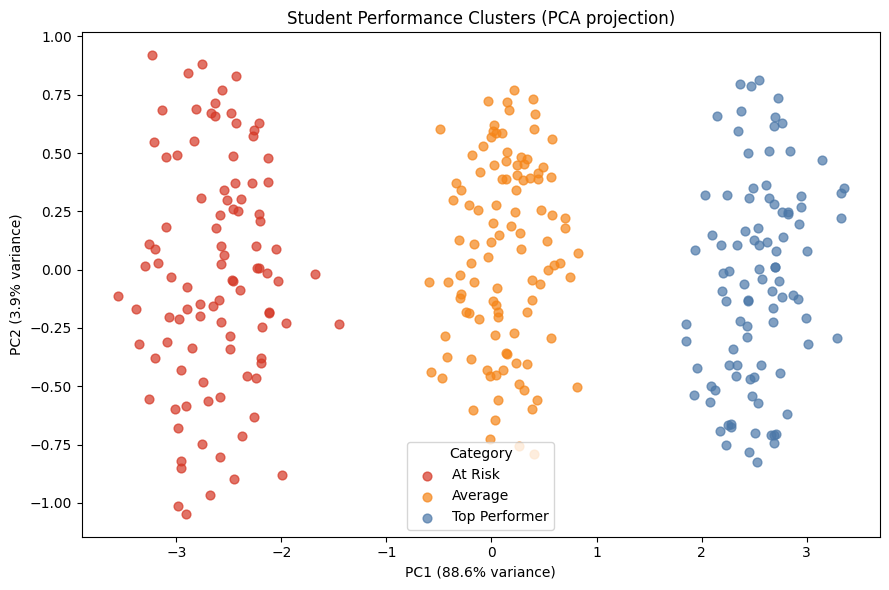

In [24]:
# ── 10. Visualisation – PCA Scatter (all 5 features → 2D) ─────────────────────
pca        = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(scaled_features)

plot_df = pd.DataFrame({
    "PC1": pca_coords[:, 0],
    "PC2": pca_coords[:, 1],
    "Category": df["performance_category"],
})

fig, ax = plt.subplots(figsize=(9, 6))
for label in ORDERED_LABELS:
    subset = plot_df[plot_df["Category"] == label]
    ax.scatter(subset["PC1"], subset["PC2"],
               label=label, color=CATEGORY_COLORS[label], alpha=0.7, s=40)

var_explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
ax.set_title("Student Performance Clusters (PCA projection)")
ax.legend(title="Category")
plt.tight_layout()
plt.show()

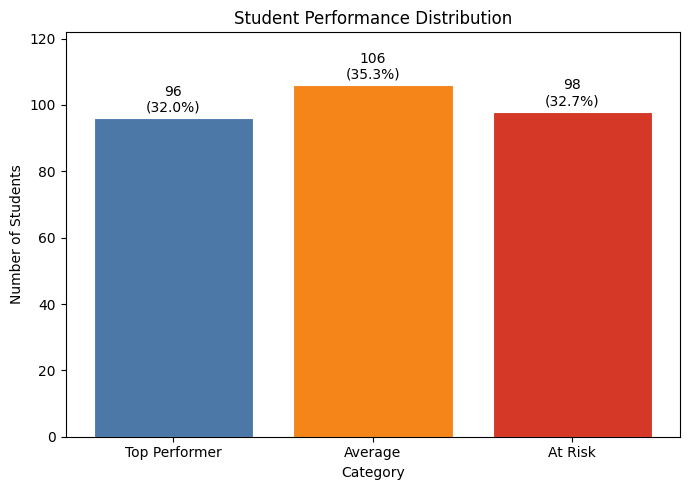

In [25]:
# ── 11. Visualisation – Performance Distribution Bar Chart ────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    category_counts.index,
    category_counts.values,
    color=[CATEGORY_COLORS[c] for c in category_counts.index],
    edgecolor="white",
    linewidth=0.8,
)

# Annotate bars with counts + percentages
for bar, count in zip(bars, category_counts.values):
    pct = count / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{count}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_title("Student Performance Distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Students")
ax.set_ylim(0, category_counts.max() * 1.15)
plt.tight_layout()
plt.show()